In [166]:
%run "/home/nichettg/Ubuntu/Laboratorio/moduli.py"

In [167]:
Rx_riferimento = 1.9515 * 1000
Rx_riferimento_err = 0.0009139826042 * 1000

data = {

    "R_A" : np.array([
            27.14,
            46.92,
            99.93,
            219.67,
            329.51,
            389.52,
            469.39,
            558.31,
            680.05,
            747.08,
            1001.9,
            1205.9,
            1496.8,
            1797.3,
            2202.7,
    ]),

    "sR_A" : np.array([
        0.04877355704,
        0.05354588811,
        0.07390535592,
        0.1349751939,
        0.1957692861,
        0.2295835581,
        0.2749102715,
        0.3256327462,
        0.3953344586,
        0.4337927794,
        0.0006142376763,
        0.0006714550014,
        0.0007610959242,
        0.0008607827392,
        0.001002899924,
    ]),


    "R_B" : np.array([
            27.17,
            46.97,
            99.8,
            220.21,
            329.66,
            389.51,
            470.38,
            560.44,
            680.25,
            746.67,
            1004.3,
            1212.4,
            1497.8,
            1799.4,
            2200.9,
    ]),

    "sR_B" : np.array([
        0.04877912429,
        0.05356049819,
        0.07384677831,
        0.1352681831,
        0.1958534449,
        0.2295779026,
        0.2754737401,
        0.3268501153,
        0.3954491381,
        0.4335574122,
        0.0006148775109,
        0.000673364127,
        0.0007614171812,
        0.0008614990378,
        0.001002254259,
    ]),

    "R_n" : np.array([
        1955.6,
        1953.6,
        1953.6,
        1946.6,
        1950.6,
        1951.6,
        1947.6,
        1944.6,
        1951.6,
        1952.6,
        1947.6,
        1941.6,
        1950.6,
        1949.6,
        1953.6,
    ]),

    "sR_n" : np.array([
        0.6066759525,
        0.6353838708,
        0.6338619274,
        0.6489028104,
        0.6472760176,
        0.6538285166,
        0.6873864719,
        0.629388503,
        0.6304407535,
        0.6495452146,
        0.636113696,
        0.6343800499,
        0.6228179413,
        0.6271128335,
        0.6255812787,
    ]),

    "k" : np.array([
        1.666666667,
        1.352569883,
        1.142857143,
        1.072961373,
        1.088139282,
        1.102941176,
        1.121914734,
        1.148545176,
        1.19379228,
        1.218026797,
        1.307189542,
        1.378676471,
        1.49551346,
        1.610305958,
        1.769911504,
    ]),

    "sk" : np.array([
        0.05064926371,
        0.0410539499,
        0.03466526908,
        0.03253868943,
        0.03300037178,
        0.03345066952,
        0.03402796134,
        0.03483838342,
        0.03621579007,
        0.03695376941,
        0.03967037977,
        0.04185018909,
        0.04541641649,
        0.04892488779,
        0.05381131626,
    ]),

    "rho" : np.array([
        0.998895841,
        0.9989354907,
        1.001302605,
        0.9975477953,
        0.9995449857,
        1.000025673,
        0.9978953187,
        0.9961994147,
        0.9997059904,
        1.000549105,
        0.9976102758,
        0.9946387331,
        0.9993323541,
        0.9988329443,
        1.000817847
    ]),

    "sigma_rho" : np.array([
        0.002537434164,
        0.001611567849,
        0.001047540664,
        0.0008667016728,
        0.0008398230726,
        0.0008335610131,
        0.0008265026096,
        0.0008216698895,
        0.0008218834713,
        0.00082161804,
        0.0008643601194,
        0.0007822325737,
        0.000718533774,
        0.000676406693,
        0.0006444807734,
    ])
}

#data["k"] = data["k"] * 10**(-6)
#data["sk"] = data["sk"] * 10**(-6)

### Slide 1

In [168]:
A = False
# Se A==True usiamo R_A, altrimenti R_B.
# Questo ci permette di fare la regressione su entrambi i set di dati senza dover riscrivere tutto il codice.
if A==True:
    quali_dati = "R_A"
else:
    quali_dati = "R_B"

xdata = np.array([data[quali_dati], data["s" + quali_dati]])
ydata = np.array([1/data["k"], data["sk"]/(data["k"]**2)])

$$
k^{-1} =
\frac{e \, x}{
(2R_n + R_e)\,x^2 
+ (2R_n^2 + 4R_n R_{\text{amp}} + 2R_n R_e + 2R_{\text{amp}} R_e)\,x 
+ R_n^2 R_e + 2R_n R_{\text{amp}} R_e
}
$$

con
$
x = R_A = R_B
$

In [169]:
"""
param_labels = ["Re", "Ramp", "e", "Rn"]

x = np.array(xdata[0])
y = np.array(ydata[0])

# slope iniziale
dx = x[1:5] - x[:4]
dy = y[1:5] - y[:4]
slope0 = np.mean(dy / dx)

d0 = 1.0
a0 = slope0 * d0

# asintotico
ratio = np.mean(x[-5:] * y[-5:])
b0 = a0 / ratio if ratio != 0 else 1.0

# intermedio
c0 = b0 * np.mean(x)

# inversione grezza
Rn0 = b0 / 4
Re0 = b0 - 2*Rn0

den = (4*Rn0 + 2*Re0)
Ramp0 = (c0 - 2*Rn0**2 - 2*Rn0*Re0) / den if den != 0 else Rn0

e0 = a0

beta0 = [Re0, Ramp0, e0, Rn0]

print(beta0)

def modello_originale(par, x):
    Re,Ramp,e,Rn = par
    return (e * x) / ((2 * Rn + Re) * x**2 + (2 * Rn**2 + 4 * Rn* Ramp + 2 * Rn * Re + 2 * Ramp * Re) * x + Rn**2 * Re + 2 * Rn * Ramp * Re)
"""

'\nparam_labels = ["Re", "Ramp", "e", "Rn"]\n\nx = np.array(xdata[0])\ny = np.array(ydata[0])\n\n# slope iniziale\ndx = x[1:5] - x[:4]\ndy = y[1:5] - y[:4]\nslope0 = np.mean(dy / dx)\n\nd0 = 1.0\na0 = slope0 * d0\n\n# asintotico\nratio = np.mean(x[-5:] * y[-5:])\nb0 = a0 / ratio if ratio != 0 else 1.0\n\n# intermedio\nc0 = b0 * np.mean(x)\n\n# inversione grezza\nRn0 = b0 / 4\nRe0 = b0 - 2*Rn0\n\nden = (4*Rn0 + 2*Re0)\nRamp0 = (c0 - 2*Rn0**2 - 2*Rn0*Re0) / den if den != 0 else Rn0\n\ne0 = a0\n\nbeta0 = [Re0, Ramp0, e0, Rn0]\n\nprint(beta0)\n\ndef modello_originale(par, x):\n    Re,Ramp,e,Rn = par\n    return (e * x) / ((2 * Rn + Re) * x**2 + (2 * Rn**2 + 4 * Rn* Ramp + 2 * Rn * Re + 2 * Ramp * Re) * x + Rn**2 * Re + 2 * Rn * Ramp * Re)\n'

In [170]:
param_labels = ["a", "b", "c", "d"]
param_labels_unit = [r"$\mu A \Omega$", r"$\Omega$", r"$\Omega^2$", r"$\Omega^3$"]

# slope iniziale
slope0 = (ydata[0][1] - ydata[0][0]) / (xdata[0][1] - xdata[0][0])

d0 = 1.0
a0 = slope0 * d0

# comportamento asintotico
ratio = np.mean(xdata[0][-5:] * ydata[0][-5:])
b0 = a0 / ratio if ratio != 0 else 1.0

# termine intermedio
c0 = b0 * np.mean(xdata[0])

beta0 = [a0, b0, c0, d0]

def modello(par, x):
    a,b,c,d = par
    return (a * x) / (b * x**2 + c * x + d)

In [171]:
"""
x1data = np.vstack([data[quali_dati], data["R_n"]])
x2data = np.vstack([data["s" + quali_dati], data["sR_n"]])
Xdata = np.array([x1data, x2data])

param_labels = ["Re", "Ramp", "e"]
def modello(par, x):
    Re, Ramp, e = par
    R, Rn = x
    return (e * R) / ((R + 2*Ramp + Rn) * (R*Re + 2*R*Rn + Re*Rn))
beta0 = [0.1, 170.0, 10.0]

anal = f.fit(Xdata,ydata,modello,beta0,chi=True)
gf.salva_analisi(anal,param_labels,"test.txt")
"""

'\nx1data = np.vstack([data[quali_dati], data["R_n"]])\nx2data = np.vstack([data["s" + quali_dati], data["sR_n"]])\nXdata = np.array([x1data, x2data])\n\nparam_labels = ["Re", "Ramp", "e"]\ndef modello(par, x):\n    Re, Ramp, e = par\n    R, Rn = x\n    return (e * R) / ((R + 2*Ramp + Rn) * (R*Re + 2*R*Rn + Re*Rn))\nbeta0 = [0.1, 170.0, 10.0]\n\nanal = f.fit(Xdata,ydata,modello,beta0,chi=True)\ngf.salva_analisi(anal,param_labels,"test.txt")\n'

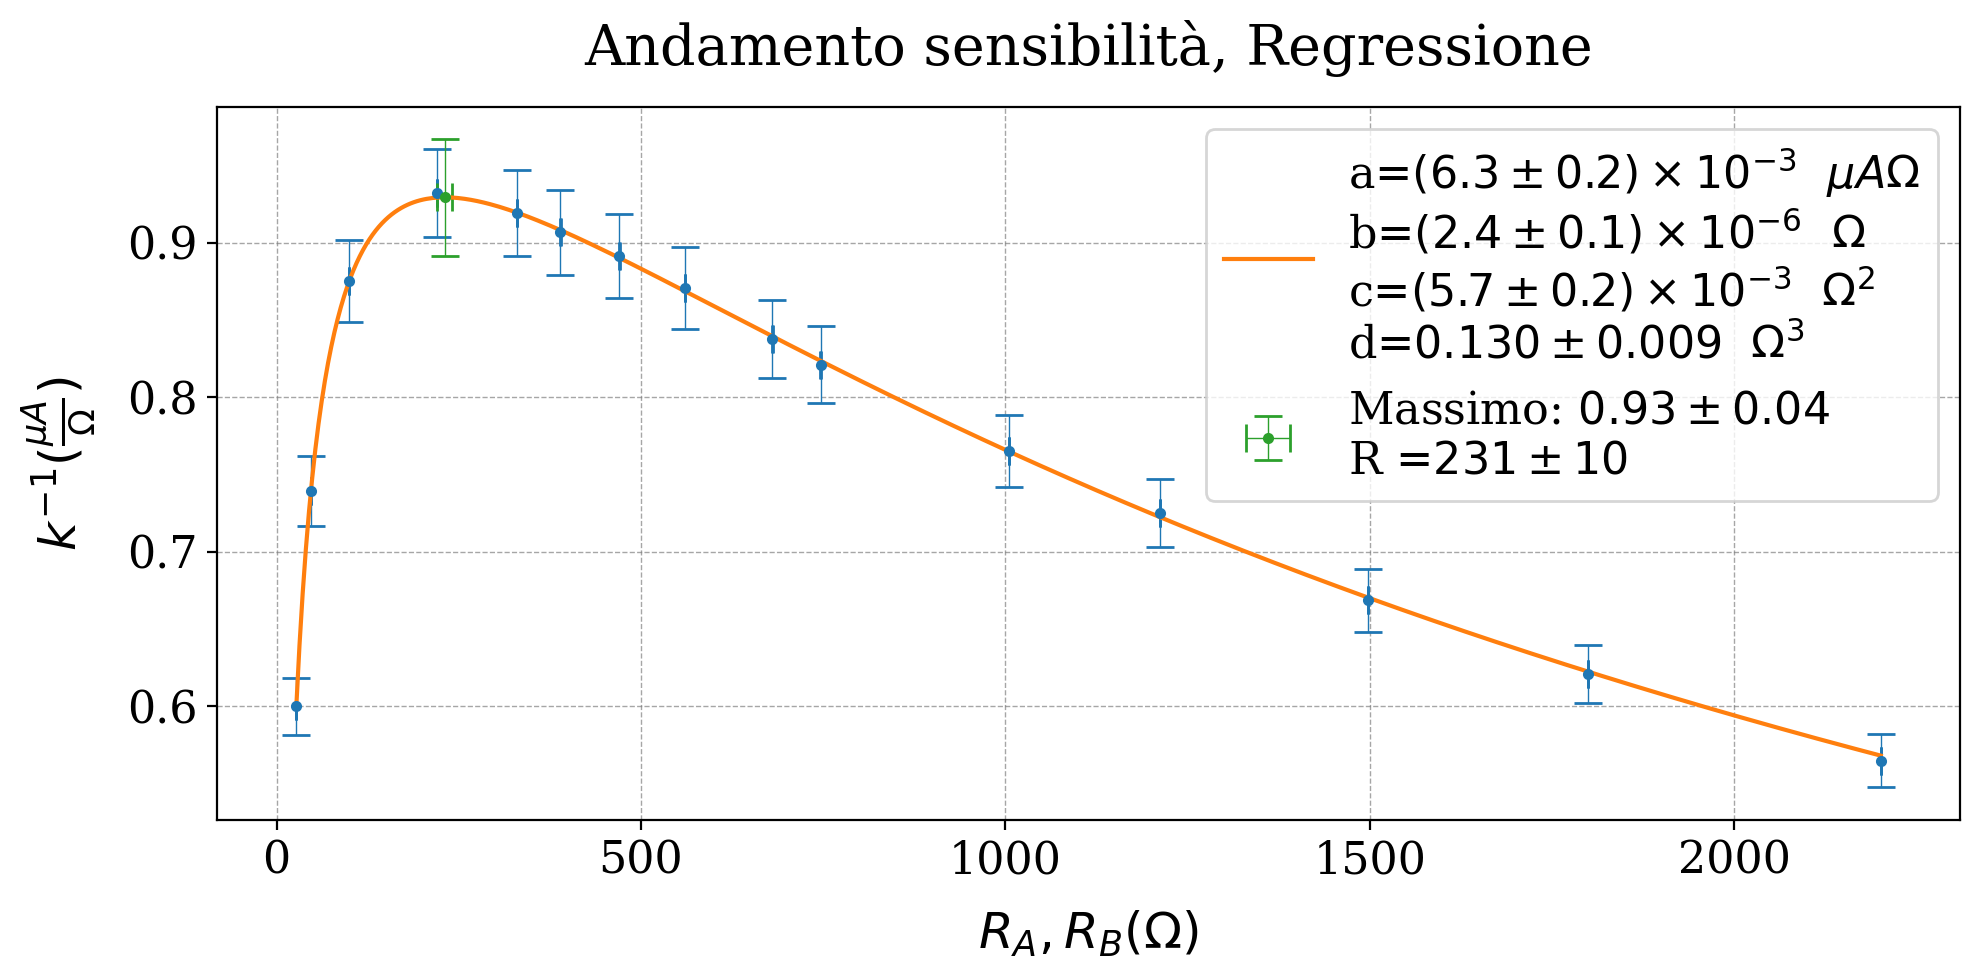

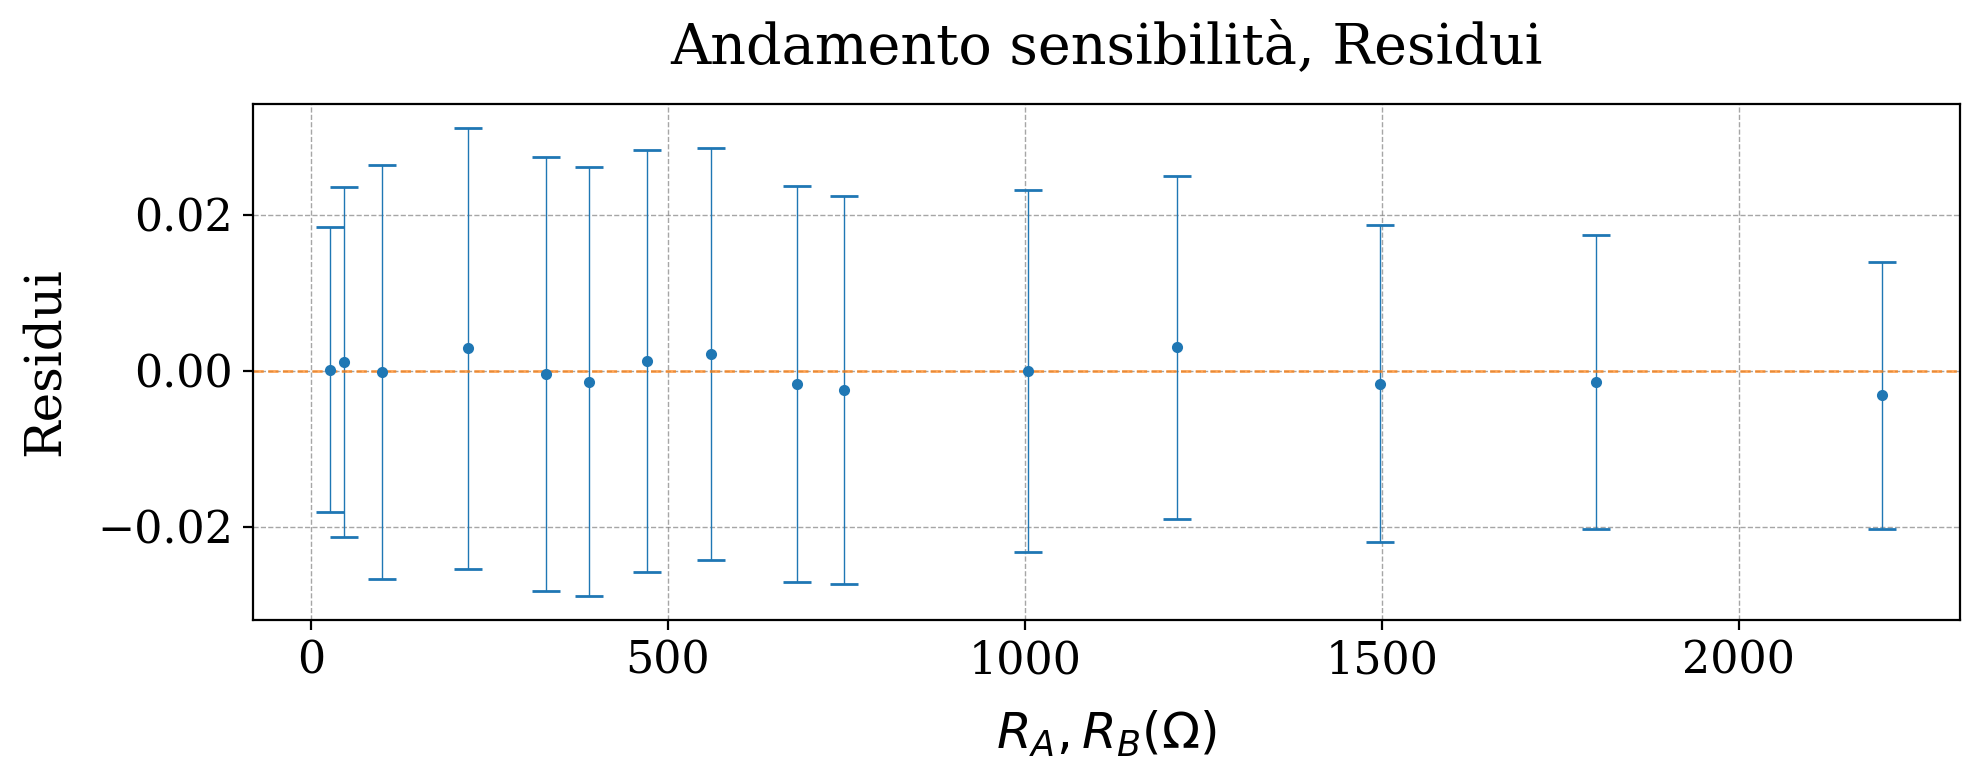

In [172]:
titolo = "Andamento sensibilità"
xlabel = r"$R_A,R_B (Ω)$"
ylabel = r"$k^{-1} (\frac{\mu A}{Ω})$"
file_output1 = "residui.txt"
file_output2 = "chi.txt"
grafico_output1 = "Slide 1.pdf"
grafico_output2 = "Slide 1, Residui.pdf"
grafico_output3 = "Slide 1, Chi.pdf"

#####################################
## Regressione
#####################################

anal = f.fit(xdata,ydata,modello,beta0,chi=True)

a,b,c,d = anal[:,0]
sa,sb,sc,sd = anal[:,1]

def xmax_e_sigma(b, d, sb, sd):
    x = np.sqrt(d / b)
    dx_db = -0.5 * np.sqrt(d) / (b**(3/2))
    dx_dd = 1 / (2 * np.sqrt(b * d))
    sx = np.sqrt((dx_db * sb)**2 + (dx_dd * sd)**2)
    return x, sx
def ymax_e_sigma(a, b, c, d, sa, sb, sc, sd):
    x = np.sqrt(d / b)
    denom = 2*d + c*x
    y = (a * x) / denom
    # derivate
    dy_da = x / denom
    dy_dc = -(a * x**2) / denom**2
    dy_dd = -(2 * a * x) / denom**2
    # catena per b
    dx_db = -0.5 * np.sqrt(d) / (b**(3/2))
    dy_dx = (2 * a * d) / denom**2
    dy_db = dy_dx * dx_db
    sy = np.sqrt(
        (dy_da * sa)**2 +
        (dy_db * sb)**2 +
        (dy_dc * sc)**2 +
        (dy_dd * sd)**2
    )
    return y, sy

x_max, sx_max = xmax_e_sigma(b, d, sb, sd)
y_max, sy_max = ymax_e_sigma(a, b, c, d, sa, sb, sc, sd)

massimo = [x_max, y_max]

#####################################
### Grafico Regressione
#####################################

fig,ax = plt.subplots(1, 1,  figsize=(10, 5))
gf.parametri_grafico(ax,titolo + ", Regressione",xlabel=xlabel,ylabel=ylabel)

# Grafico dei dati con errori
ax.errorbar(xdata[0],ydata[0],xerr=xdata[1],yerr=ydata[1], **gf.errorbar_params, color = gf.colori[0])
# Massimo
ax.errorbar(massimo[0], massimo[1],xerr=sx_max,yerr=sy_max, color=gf.colori[2], label=f"Massimo: {gf.formatta_errore(y_max, sy_max)}\nR ={gf.formatta_errore(x_max, sx_max)}", **gf.errorbar_params)
# Grafico del fit
fit_label = "\n".join(
    f"{param_labels[i]}={gf.formatta_errore(anal[i,0], anal[i,1])}" + f" {param_labels_unit[i]}"
    for i in range(len(param_labels))
)
x_fit = np.linspace(min(xdata[0]), max(xdata[0]), 500)
ax.plot(x_fit,modello(anal[:,0],x_fit),
        label=fit_label, **gf.plot_params, color = gf.colori[1])

ax.legend()

gf.salva_grafico(fig,grafico_output1)

#####################################
### Residui
#####################################

f.inizializza_output(file_output1)
res = f.residui(xdata,ydata,anal[:,0],modello,file_output1,titolo)

#####################################
### Grafico Residui
#####################################

fig,ax = plt.subplots(1, 1,  figsize=(10, 4))
gf.parametri_grafico(ax,titolo + ", Residui",xlabel=xlabel,ylabel="Residui")

ax.errorbar(res[0],res[1],yerr=res[2],
            **gf.errorbar_params, color=gf.colori[0])
ax.axhline(0,
           **gf.line_params, color=gf.colori[1])

gf.salva_grafico(fig,grafico_output2)

Se $\frac{d}{b} > 0$, i punti critici sono:
$
x = \pm \sqrt{\frac{d}{b}}
$

Il punto di massimo è:
$$
x_{\max} =
\begin{cases}
\sqrt{\frac{d}{b}} & \text{se } a > 0 \\
-\sqrt{\frac{d}{b}} & \text{se } a < 0
\end{cases}
$$

$$
y_{\max} = \frac{a \sqrt{\frac{d}{b}}}{2d + c \sqrt{\frac{d}{b}}}
$$

In [173]:
"""
import sympy as sp

def invert_params(a, b, c, d):
    Rn = sp.symbols('Rn', real=True)

    Re_expr = b - 2*Rn
    Ramp_expr = (c - 2*b*Rn + 2*Rn**2) / (2*b)

    eq = d - Rn * (Rn + 2*Ramp_expr) * Re_expr

    sols = sp.solve(eq, Rn)

    sols_real = [sol.evalf() for sol in sols if sol.is_real]

    if not sols_real:
        raise ValueError("Nessuna soluzione reale: i parametri del fit non sono compatibili.")

    # scegli quella positiva (di solito ha senso fisico)
    Rn_val = float([s for s in sols_real if s > 0][0])

    Re_val = float(b - 2*Rn_val)
    Ramp_val = float((c - 2*b*Rn_val + 2*Rn_val**2) / (2*b))
    e_val = float(a)

    return Rn_val, Re_val, Ramp_val, e_val
"""

'\nimport sympy as sp\n\ndef invert_params(a, b, c, d):\n    Rn = sp.symbols(\'Rn\', real=True)\n\n    Re_expr = b - 2*Rn\n    Ramp_expr = (c - 2*b*Rn + 2*Rn**2) / (2*b)\n\n    eq = d - Rn * (Rn + 2*Ramp_expr) * Re_expr\n\n    sols = sp.solve(eq, Rn)\n\n    sols_real = [sol.evalf() for sol in sols if sol.is_real]\n\n    if not sols_real:\n        raise ValueError("Nessuna soluzione reale: i parametri del fit non sono compatibili.")\n\n    # scegli quella positiva (di solito ha senso fisico)\n    Rn_val = float([s for s in sols_real if s > 0][0])\n\n    Re_val = float(b - 2*Rn_val)\n    Ramp_val = float((c - 2*b*Rn_val + 2*Rn_val**2) / (2*b))\n    e_val = float(a)\n\n    return Rn_val, Re_val, Ramp_val, e_val\n'

### Slide 2

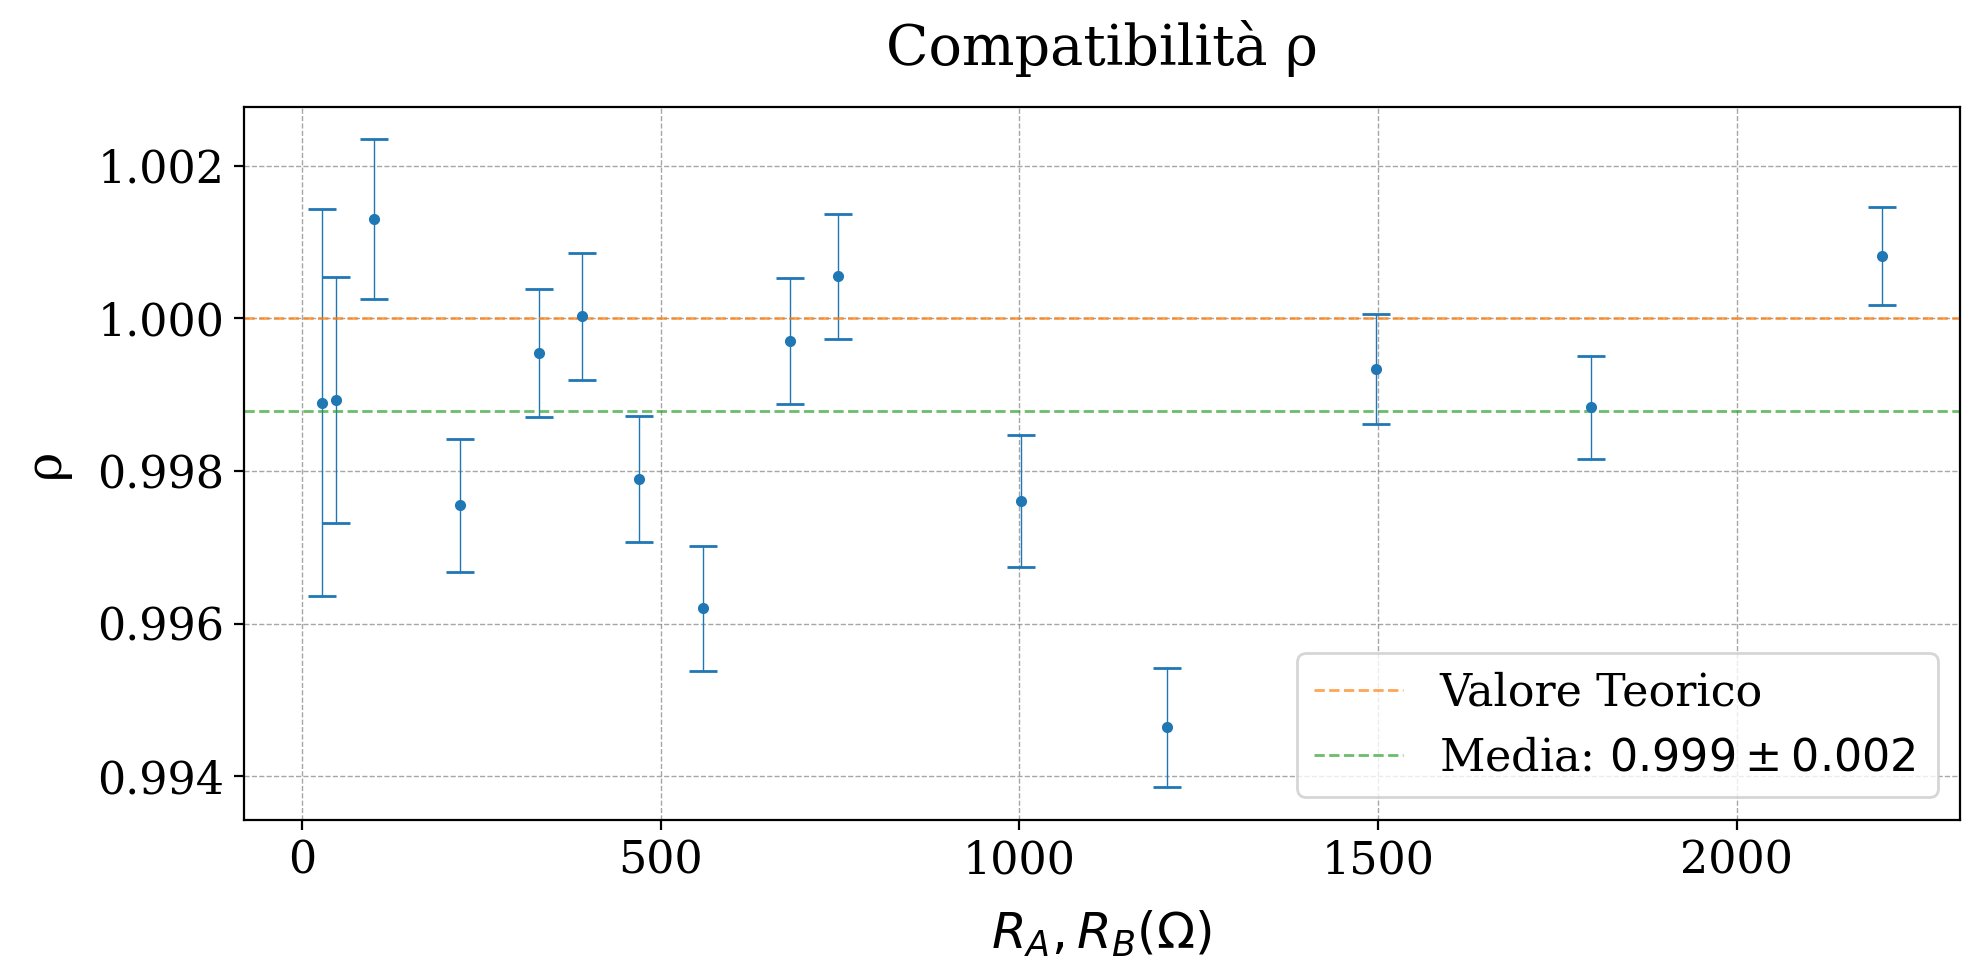

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


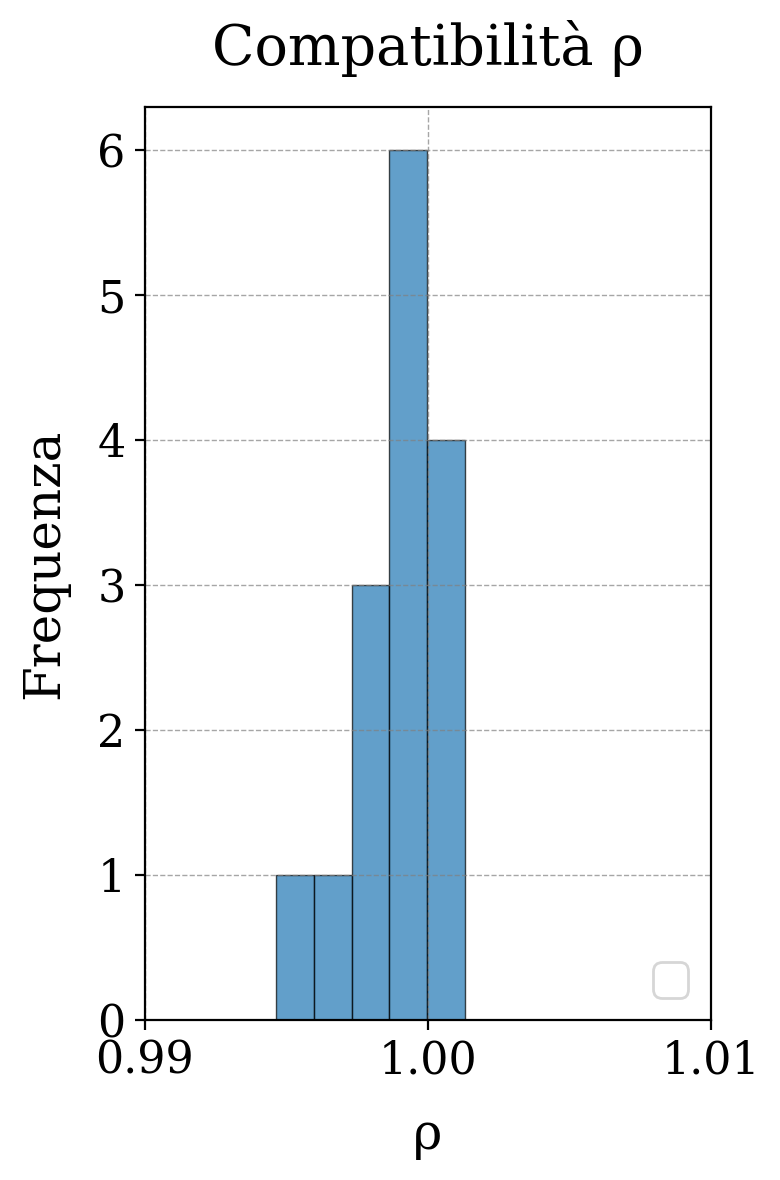

In [174]:
dati = data["rho"]
errori = data["sigma_rho"]

# Grafico 1
fig,ax = plt.subplots(1, 1,  figsize=(10, 5), sharex=True, sharey=True)
gf.parametri_grafico(ax,"Compatibilità ρ",xlabel=r"$R_A, R_B (Ω)$",ylabel="ρ")
ax.errorbar(data["R_A"],dati,errori, color=gf.colori[0], **gf.errorbar_params)
ax.axhline(y=1, color=gf.colori[1], label="Valore Teorico", **gf.line_params)
errore = 0.001721694905
ax.axhline(y=np.mean(dati), color=gf.colori[2], **gf.line_params, label=f"Media: {gf.formatta_errore(np.mean(dati),errore)}")

plt.legend(loc="lower right", frameon=True)
gf.salva_grafico(fig,"Slide 2.1.pdf")

# Grafico 2
fig,ax = plt.subplots(1, 1,  figsize=(4, 6), sharex=True, sharey=True)
gf.parametri_grafico(ax,"Compatibilità ρ",xlabel=r"ρ",ylabel="Frequenza")
plt.hist(dati,bins=5,color=gf.colori[0],
    edgecolor='black',  # contorno nero
    linewidth=0.5,      # spessore linea sottile
    alpha=0.7           # trasparenza barre
)
ax.set_xlim(0.99, 1.01)

plt.legend(loc="lower right", frameon=True)
gf.salva_grafico(fig,"Slide 2.2.pdf")

### Slide 3

In [175]:
risultati = {
    "Metodo A": {
        "valori": [
            1952.495029,
            1956.878672,
            1952.013541,
            1952.977437,
            1952.486997
        ],
        "casuale": [
            0.62252,
            10.98559261,
            1.021434682,
            0.6627511899,
            0.929403498
        ],
        "totale": [
            0.8945135789,
            11.00435679,
            1.206628444,
            0.9229639929,
            1.129785048
        ]
    },
    "Metodo B": {
        "valori": [
            1953.357057,
            1953.76924,
            1953.456623,
            1953.257877,
            1953.302555
        ],
        "casuale": [
            1.06228,
            1.85249547,
            1.490982329,
            1.249007674,
            0.9249828714
        ],
        "totale": [
            1.24139526,
            1.960704684,
            1.623469032,
            1.404508299,
            1.12615128
        ]
    }
}

In [176]:
# Digitare "True" se si vogliono due grafici separati
separati = False
offset = 0.02

In [177]:
labels = [r"${R_x}^*$", r"${R_x}^{*, no-rej}$", r"${R_n}^{0,dir,corr}$", r"${R_n}^{0,inv,corr}$", r"${R_x}^{*, no-corr}$"]
x = np.array([1,2,3,4,5])

if separati:
    for i, (metodo,dati)  in enumerate(risultati.items()):

        fig,ax = plt.subplots(1, 1,  figsize=(10, 5))
        gf.parametri_grafico(ax,metodo,xlabel="",ylabel="R (Ω)")

        ax.set_xticks(x)
        ax.set_xticklabels(labels)
        ax.errorbar(x + offset, dati["valori"], dati["casuale"], color=gf.colori[0], label="Errore casuale", **gf.errorbar_params)
        ax.errorbar(x - offset, dati["valori"], dati["totale"], label="Errore totale", color=gf.colori[1], **gf.errorbar_params)

        ax.axhline(y=Rx_riferimento, color=gf.colori[2], **gf.line_params_, label=f"METRIX: \n({gf.formatta_errore(Rx_riferimento, Rx_riferimento_err)}) Ω")
        ax.axhline(y=Rx_riferimento + Rx_riferimento_err, color=gf.colori[2], **gf.line_params)
        ax.axhline(y=Rx_riferimento - Rx_riferimento_err, color=gf.colori[2], **gf.line_params)
        ax.legend(loc="upper right", frameon=True)
        gf.salva_grafico(fig,f"Slide 3.{i+1}.pdf")

In [178]:
separati = False

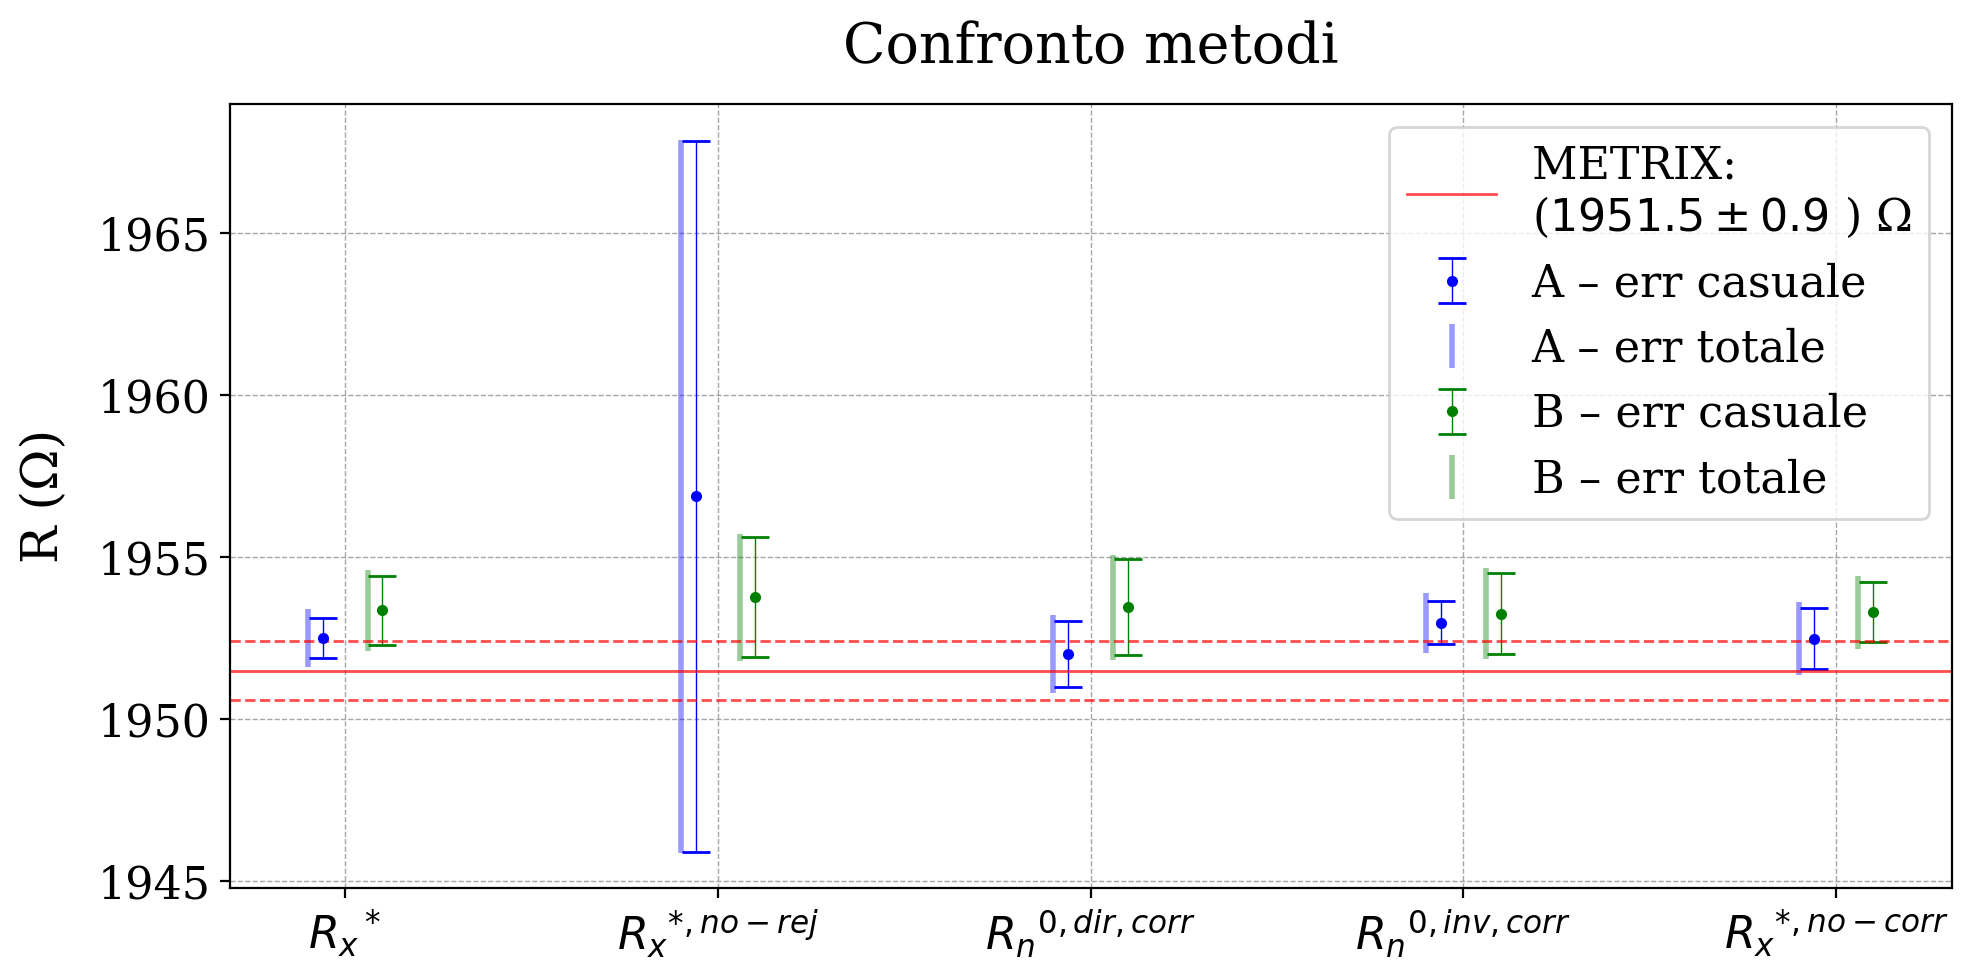

In [179]:
if not separati:
    fig, ax = plt.subplots(1,1, figsize=(10,5))
    gf.parametri_grafico(ax, "Confronto metodi", xlabel="", ylabel="R (Ω)")

    ax.set_xticks(x)
    ax.set_xticklabels(labels)

    colori = {
        "Metodo A": "blue",
        "Metodo B": "green"
    }

    offset_val = {
        "Metodo A": -4*offset,
        "Metodo B": 4*offset
    }

    metod = ["A","B"]

    for i,(metodo,dati) in enumerate(risultati.items()):

        x_plot = x + offset_val[metodo]

        ax.errorbar(
            x_plot + offset,
            dati["valori"],
            dati["casuale"],
            color=colori[metodo],
            label=f"{metod[i]} – err casuale",
            **gf.errorbar_params
        )

        ax.errorbar(
            x_plot - offset,
            dati["valori"],
            dati["totale"],
            fmt="none",
            color=colori[metodo],
            alpha=0.4,
            label=f"{metod[i]} – err totale",
            #**gf.errorbar_params
        )

    ax.axhline(y=Rx_riferimento, color="red", label=f"METRIX: \n({gf.formatta_errore(Rx_riferimento, Rx_riferimento_err)}) Ω", **gf.line_params_)
    ax.axhline(y=Rx_riferimento + Rx_riferimento_err, color="red", **gf.line_params)
    ax.axhline(y=Rx_riferimento - Rx_riferimento_err, color="red", **gf.line_params)

    # Legenda fuori
    #ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=True)
    # Legenda dentro
    ax.legend(loc="upper right", frameon=True)
    gf.salva_grafico(fig, "Slide 3.pdf")